#### Dependencies

In [408]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from sklearn.model_selection import KFold
from scipy.stats import gaussian_kde, norm
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

import statsmodels.api as sm

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

from lifelines.statistics import logrank_test

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

#### Datasets

In [409]:
lical0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/lical0_processed_data_for_fp_model_21-01-2026.csv')
miro0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miro0_processed_data_for_fp_model_21-01-2026.csv')
ril_3010 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/ril_3010_processed_data_for_fp_model_21-01-2026.csv')

# miroli0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miroli0_processed_data_for_fp_model_21-01-2026.csv')
proact0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/proact0_processed_data_for_fp_model_21-01-2026.csv')

MND_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_licals.csv')
MND_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_mirocals.csv')
MND_rilu = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_riluzole.csv')

In [410]:
proact0 = proact0[proact0['Disease_Duration'] < 120]

##### Proact with eligibility criteria

In [411]:
proact_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_miro_full.csv')
proact_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_lica_full.csv')

proact_miro['slope'] = (48 - proact_miro['ALSFRS_RT']) / proact_miro['Disease_Duration']
proact_lica['slope'] = (48 - proact_lica['ALSFRS_RT']) / proact_lica['Disease_Duration']

binss = [-np.inf, 0.31, 1.17, np.inf]
labelss = ["Slow", "Intermediate", "Fast"]

proact_miro["Progression_group"] = pd.cut(proact_miro["slope"], bins=binss, labels=labelss)
proact_lica["Progression_group"] = pd.cut(proact_lica["slope"], bins=binss, labels=labelss)


proact_miro['Study_Arm_Placebo'] = (proact_miro['Study_Arm'] == 'Placebo').astype(int)
proact_lica['Study_Arm_Placebo'] = (proact_lica['Study_Arm'] == 'Placebo').astype(int)

proact_miro = proact_miro[['subject_id', 'Event', 'Vital_Capacity_l_std', 'Sex_Male', 'Onset_Limb', 'Study_Arm_Placebo', 'Age_std', 'Diagnosis_delay_l_std', 'Disease_Duration', 'TRICALS', 'Sex_onset',	'Age_Sex', 'Age_onset', 'Age_sq', "Progression_group"]]
proact_lica = proact_lica[['subject_id', 'Event', 'Vital_Capacity_l_std', 'Sex_Male', 'Onset_Limb', 'Study_Arm_Placebo', 'Age_std', 'Diagnosis_delay_l_std', 'Disease_Duration', 'TRICALS', 'Sex_onset',	'Age_Sex', 'Age_onset', 'Age_sq', "Progression_group"]]

proact_miro = proact_miro.rename(columns={'Age_std': 'Age', 'Diagnosis_delay_l_std': 'Diagnostic_Delay', 'Vital_Capacity_l_std': 'Vital_capacity'})
proact_lica = proact_lica.rename(columns={'Age_std': 'Age', 'Diagnosis_delay_l_std': 'Diagnostic_Delay', 'Vital_Capacity_l_std': 'Vital_capacity'})


# print(f"proact_miro: {proact_miro.shape} | proact_lica: {proact_lica.shape}")
proact_lica.head(2)

,subject_id,Event,Vital_capacity,Sex_Male,Onset_Limb,Study_Arm_Placebo,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_onset,Age_Sex,Age_onset,Age_sq,Progression_group
0,1333,1,0.257074,0,1,0,-0.428923,0.605487,22.996058,-3.779545,0,-0.000000,-0.428923,0.183975,Fast
1,3350,0,1.381487,1,1,0,1.305237,0.462062,21.747700,-4.907534,1,1.305237,1.305237,1.703642,Intermediate


#### **Select only the treatment arm**

In [412]:
lical0_trt = lical0[lical0['Study_Arm_Placebo'] == 0].copy()
miro0_trt = miro0[miro0['Study_Arm_Placebo'] == 0].copy()
# miroli0_trt = miroli0[miroli0['Study_Arm_Placebo'] == 0].copy()
ril_3010_trt = ril_3010[ril_3010['Study_Arm_Placebo'] == 0].copy()
proact0_trt = proact0[proact0['Study_Arm_Placebo'] == 0].copy() 

#### **Select only the placebo arm**

In [413]:
lical0_pla = lical0[lical0['Study_Arm_Placebo'] == 1].copy()
miro0_pla = miro0[miro0['Study_Arm_Placebo'] == 1].copy()
# miroli0_pla = miroli0[miroli0['Study_Arm_Placebo'] == 1].copy()
ril_3010_pla = ril_3010[ril_3010['Study_Arm_Placebo'] == 1].copy()
proact0_pla = proact0[proact0['Study_Arm_Placebo'] == 1].copy() 

In [414]:
proact_miro_pla = proact_miro[proact_miro['Study_Arm_Placebo'] == 1]
proact_lica_pla = proact_lica[proact_lica['Study_Arm_Placebo'] == 1]

proact_miro_trt = proact_miro[proact_miro['Study_Arm_Placebo'] == 0]
proact_lica_trt = proact_lica[proact_lica['Study_Arm_Placebo'] == 0]

print(f"proact_miro_trt: {proact_miro_trt.shape} | proact_lica_trt: {proact_lica_trt.shape}\n")
print(f"proact_miro_pla: {proact_miro_pla.shape} | proact_lica_pla: {proact_lica_pla.shape}\n")
proact_lica_pla.head(2)

proact_miro_trt: (240, 15) | proact_lica_trt: (346, 15)

proact_miro_pla: (188, 15) | proact_lica_pla: (281, 15)



,subject_id,Event,Vital_capacity,Sex_Male,Onset_Limb,Study_Arm_Placebo,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_onset,Age_Sex,Age_onset,Age_sq,Progression_group
3,4753,1,-0.336316,0,1,1,-1.902391,-1.024997,14.586071,-2.589279,0,-0.0,-1.902391,3.619093,Fast
5,7540,0,0.043730,0,1,1,0.704515,0.685898,20.400788,-4.593248,0,0.0,0.704515,0.496341,Intermediate


In [415]:
print(f"Miro: {miro0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
# print(f"miroli: {miroli0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"Lical :{lical0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"Riluzole: {ril_3010_pla.Disease_Duration.describe().round(2).to_dict()}\n")

print(f"Proact: {proact0_pla.Disease_Duration.describe().round(2).to_dict()}\n")

print(f"MND_lica: {MND_lica.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"MND_miro: {MND_miro.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"MND_rilu: {MND_rilu.Disease_Duration.describe().round(2).to_dict()}\n")

Miro: {'count': 110.0, 'mean': 29.04, 'std': 8.09, 'min': 8.05, '25%': 25.14, '50%': 29.35, '75%': 34.32, 'max': 44.92}

Lical :{'count': 87.0, 'mean': 31.76, 'std': 8.63, 'min': 10.86, '25%': 24.95, '50%': 34.81, '75%': 37.67, 'max': 46.14}

Riluzole: {'count': 242.0, 'mean': 13.41, 'std': 5.41, 'min': 0.3, '25%': 9.2, '50%': 15.82, '75%': 17.94, 'max': 20.7}

Proact: {'count': 1547.0, 'mean': 29.64, 'std': 11.36, 'min': 4.66, '25%': 21.83, '50%': 27.9, '75%': 35.41, 'max': 100.1}

MND_lica: {'count': 146.0, 'mean': 23.87, 'std': 7.56, 'min': 7.13, '25%': 18.32, '50%': 24.56, '75%': 30.42, 'max': 35.94}

MND_miro: {'count': 92.0, 'mean': 18.8, 'std': 5.62, 'min': 5.22, '25%': 14.82, '50%': 19.73, '75%': 24.08, 'max': 27.92}

MND_rilu: {'count': 169.0, 'mean': 29.55, 'std': 11.92, 'min': 5.65, '25%': 20.86, '50%': 29.53, '75%': 36.24, 'max': 59.92}



#### Choosing cohorts

In [416]:
MND_lica.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq',
       'TRICALS_Risk_Score'],
      dtype='object')

In [417]:
lical0_trt.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Study_Arm_Placebo', 'Age',
       'TRICALS', 'Diagnostic_Delay', 'Vital_capacity', 'Onset_Limb',
       'Sex_Male', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_TRICALS',
       'Age_VC', 'Sex_VC', 'Onset_VC', 'Age_sq'],
      dtype='object')

In [418]:
MND_miro['Study_Arm_Placebo'] = 1
MND_lica['Study_Arm_Placebo'] = 1

MND_miro = MND_miro.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
MND_lica = MND_lica.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})

miro0_trt_mnd = miro0_trt[['subject_id', 'Event', 'Disease_Duration','Study_Arm_Placebo', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq', 'TRICALS']]
lical0_trt_mnd = lical0_trt[['subject_id', 'Event', 'Disease_Duration','Study_Arm_Placebo', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq', 'TRICALS']]


miro_trt_trical = miro0_trt[(miro0_trt['TRICALS'] >= -6) & (miro0_trt['TRICALS'] <= -2)]
MND_miro_trical = MND_miro[(MND_miro['TRICALS'] >= -6) & (MND_miro['TRICALS'] <= -2)]

lica_trt_trical = lical0_trt[(lical0_trt['TRICALS'] >= -6) & (lical0_trt['TRICALS'] <= -2)]
MND_lica_trical = MND_lica[(MND_lica['TRICALS'] >= -6) & (MND_lica['TRICALS'] <= -2)]


In [419]:
# combine mirocals treated and licals placebo
comb = pd.concat([lical0_trt, MND_lica], axis=0, ignore_index=True)
comb['Group'] = (comb['Study_Arm_Placebo'] == 0).astype(int)
comb.shape

(235, 19)

In [420]:
comb.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1


In [421]:
# ============================================================
# PROPENSITY SCORE + OVERLAP
# ============================================================
def fit_propensity_score(
    df: pd.DataFrame,
    covariates: List[str],
    penalty: str = "l2",
    C: float = 1.0
) -> Tuple[pd.DataFrame, Pipeline]:
    """
    Logistic PS model: probability of being in treated trial arm.
    Missing numeric values are median-imputed.
    """
    x = df[covariates].copy()
    y = df["Group"].astype(int).values

    numeric_features = covariates
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver="lbfgs",
        max_iter=5000
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x, y)
    ps = pipe.predict_proba(x)[:, 1]

    out = df.copy()
    out["ps"] = ps
    out["ps_logit"] = np.log(np.clip(ps, 1e-6, 1-1e-6) / np.clip(1-ps, 1e-6, 1-1e-6))

    auc = roc_auc_score(y, ps)
    print(f"Propensity model AUC: {auc:.3f}")

    return out, pipe

In [422]:
covariates = ['Disease_Duration', 'Age', 'Diagnostic_Delay', 'Onset_Limb', 'Sex_Male'] #, 'Vital_capacity']

comb_ps, propen = fit_propensity_score(comb, covariates)
# 
comb_ps.head(2)

Propensity model AUC: 0.775


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1,0.656577,0.648077
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1,0.717652,0.932844


In [423]:
# Trim non overlapping records
def trim_nonoverlap(df: pd.DataFrame, ps_col: str = "ps") -> pd.DataFrame:
    """
    Trim non-overlapping tails:
      treated above max(control) and control below min(treated)
    """
    x = df.copy()
    ps_t = x.loc[x["Group"] == 1, ps_col]
    ps_c = x.loc[x["Group"] == 0, ps_col]

    lower = ps_t.min()
    upper = ps_c.max()

    # More symmetric overlap region
    lower_common = max(ps_t.min(), ps_c.min())
    upper_common = min(ps_t.max(), ps_c.max())

    trimmed = x[(x[ps_col] >= lower_common) & (x[ps_col] <= upper_common)].copy()

    print(f"Before trimming: {len(x)}")
    print(f"After trimming:  {len(trimmed)}")
    print(f"Removed:         {len(x) - len(trimmed)}")

    return trimmed.reset_index(drop=True)

trim_propen = trim_nonoverlap(comb_ps, "ps")
# trim_propen

Before trimming: 235
After trimming:  207
Removed:         28


In [424]:
# make treated and contral groups more comparable
def add_weights(df: pd.DataFrame, method: str = "overlap", ps_col: str = "ps") -> pd.DataFrame:
    """
    Supported:
      - overlap
      - iptw
      - unstabilized
    """
    x = df.copy()
    ps = np.clip(x[ps_col].values, 1e-6, 1 - 1e-6)
    g = x["Group"].values

    if method == "overlap":
        w = np.where(g == 1, 1 - ps, ps)
    elif method in ("iptw", "unstabilized"):
        w = np.where(g == 1, 1 / ps, 1 / (1 - ps))
    else:
        raise ValueError("method must be 'overlap' or 'iptw'")

    x["weight"] = w
    return x

comb_weight = add_weights(comb_ps)
comb_weight.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit,weight
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1,0.656577,0.648077,0.343423
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1,0.717652,0.932844,0.282348


In [425]:
# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd_continuous(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        mt = np.nanmean(x_t)
        vt = np.nanvar(x_t, ddof=0)
    else:
        mt = weighted_mean(x_t, w_t)
        vt = weighted_var(x_t, w_t)

    if w_c is None:
        mc = np.nanmean(x_c)
        vc = np.nanvar(x_c, ddof=0)
    else:
        mc = weighted_mean(x_c, w_c)
        vc = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (mt - mc) / pooled_sd


def smd_binary(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        pt = np.nanmean(x_t)
    else:
        pt = weighted_mean(x_t, w_t)

    if w_c is None:
        pc = np.nanmean(x_c)
    else:
        pc = weighted_mean(x_c, w_c)

    p = (pt + pc) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (pt - pc) / denom


def balance_table(df: pd.DataFrame, covariates: List[str], weight_col: Optional[str] = None) -> pd.DataFrame:
    rows = []

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    for col in covariates:
        xt = treated[col].astype(float)
        xc = control[col].astype(float)

        mask_t = xt.notna()
        mask_c = xc.notna()
        xt = xt[mask_t]
        xc = xc[mask_c]

        wt = treated.loc[mask_t, weight_col].values if weight_col is not None else None
        wc = control.loc[mask_c, weight_col].values if weight_col is not None else None

        uniq = pd.concat([xt, xc]).dropna().unique()
        is_binary = set(np.unique(uniq)).issubset({0.0, 1.0})

        if is_binary:
            smd = smd_binary(xt, xc, wt, wc)
        else:
            smd = smd_continuous(xt, xc, wt, wc)

        if weight_col is None:
            mt = np.nanmean(xt)
            mc = np.nanmean(xc)
        else:
            mt = weighted_mean(xt.values, wt)
            mc = weighted_mean(xc.values, wc)

        rows.append({
            "Variable": col,
            "Treated_mean": mt,
            "Control_mean": mc,
            "SMD": smd,
            "Abs_SMD": np.abs(smd)
        })

    out = pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False).reset_index(drop=True)
    return out

comb_baln = balance_table(comb_weight, covariates, 'weight')
comb_baln

,Variable,Treated_mean,Control_mean,SMD,Abs_SMD
0,Onset_Limb,0.782667,0.771905,0.025866,0.025866
1,Sex_Male,0.711054,0.700417,0.023340,0.023340
2,Diagnostic_Delay,-0.202347,-0.184561,-0.016537,0.016537
3,Age,-0.005431,-0.008815,0.003375,0.003375
4,Disease_Duration,26.982567,26.971588,0.001302,0.001302


In [426]:
# ============================================================
# SURVIVAL ANALYSIS
# ============================================================
def weighted_km_plot(
    df: pd.DataFrame,
    time_col: str = "Time",
    event_col: str = "Event",
    weight_col: Optional[str] = "weight",
    title: str = "Weighted Kaplan-Meier",
    x_max: Optional[float] = None
):
    plt.figure(figsize=(5, 4))

    km_t = KaplanMeierFitter()
    km_c = KaplanMeierFitter()

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    km_t.fit(
        durations=treated[time_col],
        event_observed=treated[event_col],
        weights=treated[weight_col] if weight_col else None,
        label="Treated"
    )
    km_c.fit(
        durations=control[time_col],
        event_observed=control[event_col],
        weights=control[weight_col] if weight_col else None,
        label="External control"
    )

    ax = km_t.plot_survival_function(ci_show=True)
    km_c.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlabel("Disease Duration")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.set_ylim(0,1.02)
    ax.grid(True, alpha=0.3)
    if x_max is not None:
        ax.set_xlim(0, x_max)
    plt.tight_layout()
    plt.show()
    

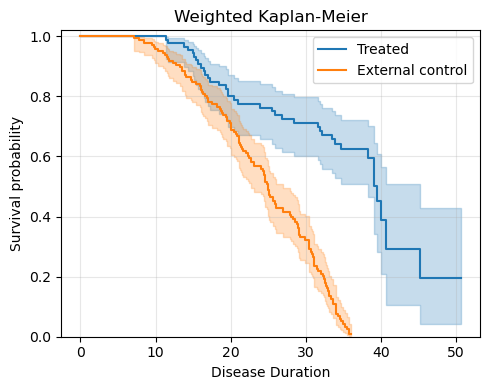

In [427]:
weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = None)

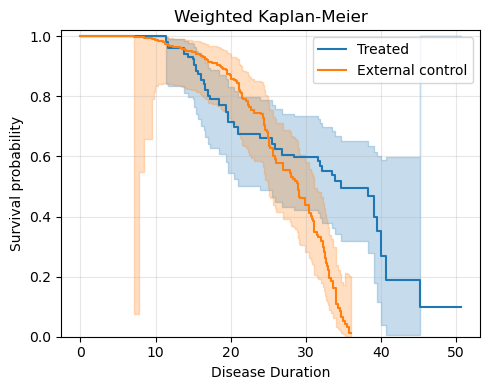

In [428]:
weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = "weight")

#### **Helper function**

In [429]:
# ============================================================
# Basic helpers
# ============================================================
def weighted_mean_np(x: np.ndarray, w: np.ndarray | None = None) -> float:
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x))
    w = np.asarray(w, float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not np.any(ok):
        return np.nan
    return float(np.sum(w[ok] * x[ok]) / np.sum(w[ok]))


def _logit(p: float) -> float:
    p = float(np.clip(p, 1e-12, 1 - 1e-12))
    return float(np.log(p / (1 - p)))


def ci_str(lo, hi, digits=3):
    if lo is None or hi is None or (not np.isfinite(lo)) or (not np.isfinite(hi)):
        return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"



In [430]:
dat_set = comb_weight[comb_weight['Study_Arm_Placebo'] == 1]
dat_set.head(3)


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit,weight
89,32,0,35.939553,1,0.702283,-5.485294,1.788664,NaN,1,1,1,0.702283,0.702283,NaN,NaN,NaN,NaN,0.493202,0,0.427744,-0.291062,0.427744
90,257,1,7.785808,1,-0.704137,-2.531038,-1.412725,NaN,0,1,0,-0.704137,-0.000000,NaN,NaN,NaN,NaN,0.495810,0,0.074562,-2.518631,0.074562
91,1086,1,21.222076,1,0.594471,-2.607816,-1.272427,NaN,0,0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,0.353396,0,0.278284,-0.952992,0.278284


In [431]:
dat_set.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Study_Arm_Placebo', 'Age',
       'TRICALS', 'Diagnostic_Delay', 'Vital_capacity', 'Onset_Limb',
       'Sex_Male', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_TRICALS',
       'Age_VC', 'Sex_VC', 'Onset_VC', 'Age_sq', 'Group', 'ps', 'ps_logit',
       'weight'],
      dtype='object')

In [432]:
covariates = ['Age', 'TRICALS', 'Diagnostic_Delay', 'Onset_Limb',
        'Sex_Male', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq']

In [433]:
# list(covariates)

In [434]:
# ============================================================
# Data prep
# ============================================================
def build_analysis_df(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    needed = [time_col, event_col] + list(covariates)
    if weight_col is not None and weight_col in df.columns:
        needed += [weight_col]

    out = df.loc[:, needed].copy()

    for c in [time_col, event_col] + list(covariates):
        out[c] = pd.to_numeric(out[c], errors = "coerce")

    if weight_col is not None and weight_col in out.columns:
        out[weight_col] = pd.to_numeric(out[weight_col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if weight_col is not None and weight_col in out.columns:
        out = out[np.isfinite(out[weight_col]) & out[weight_col] > 0].reset_index(drop=True)

    out[event_col] = out[event_col].astype(int)
    return out


df = build_analysis_df(
    df = dat_set,
    covariates = covariates,
    weight_col = "weight",
    time_col = "Disease_Duration",
    event_col = "Event",
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Disease_Duration  146 non-null    float64
 1   Event             146 non-null    int64  
 2   Age               146 non-null    float64
 3   TRICALS           146 non-null    float64
 4   Diagnostic_Delay  146 non-null    float64
 5   Onset_Limb        146 non-null    int64  
 6   Sex_Male          146 non-null    int64  
 7   Sex_onset         146 non-null    int64  
 8   Age_Sex           146 non-null    float64
 9   Age_onset         146 non-null    float64
 10  Age_sq            146 non-null    float64
 11  weight            146 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 13.8 KB


In [435]:
def prep_df(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    return build_analysis_df(df, covariates, weight_col, time_col, event_col)

df  =  prep_df(
    df = df,
    covariates = covariates,
    weight_col = "weight",
    time_col = "Disease_Duration",
    event_col = "Event",
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Disease_Duration  146 non-null    float64
 1   Event             146 non-null    int64  
 2   Age               146 non-null    float64
 3   TRICALS           146 non-null    float64
 4   Diagnostic_Delay  146 non-null    float64
 5   Onset_Limb        146 non-null    int64  
 6   Sex_Male          146 non-null    int64  
 7   Sex_onset         146 non-null    int64  
 8   Age_Sex           146 non-null    float64
 9   Age_onset         146 non-null    float64
 10  Age_sq            146 non-null    float64
 11  weight            146 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 13.8 KB


In [436]:


# ============================================================
# KM helpers
# ============================================================
def km_surv_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in df.columns:
        kmf.fit(df[time_col],  event_observed=df[event_col], weights = df[weight_col])
    else:
        kmf.fit(df[time_col], event_observed=df[event_col])

    surv = kmf.predict(t0_months)
    return float(surv) if np.isfinite(surv) else np.nan

km_surv_at_t0(
    df = df,
    t0_months = 20,
    time_col = "Disease_Duration",
    event_col = "Event",
    weight_col = "weight",
)

0.8716198326493801

In [437]:
def km_risk_ci_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
):
    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in df.columns:
        kmf.fit(df[time_col], event_observed=df[event_col], weights = df[weight_col])
    else:
        kmf.fit(df[time_col], event_observed=df[event_col])

    times = kmf.survival_function_.index.to_numpy()
    times = times[times <= t0_months]
    if len(times) == 0:
        return np.nan, np.nan, np.nan

    t_use = float(np.max(times))
    s = float(kmf.predict(t_use))
    ci = kmf.confidence_interval_survival_function_

    lo_ci = ci.columns[0]
    hi_ci = ci.columns[1]
    lo = float(ci.loc[t_use, lo_ci])
    hi = float(ci.loc[t_use, hi_ci])

    risk = 1 - s
    risk_lo = 1 - hi
    risk_hi = 1 - lo

    return float(risk), float(risk_lo), float(risk_hi)

km_risk_ci_at_t0(
    df = df,
    t0_months = 20,
    time_col = "Disease_Duration",
    event_col = "Event",
    weight_col = "weight",
)

(0.12838016735061986, 0.05769400890480847, 0.2721775983230059)

In [438]:
df.shape

(146, 12)

In [439]:
# ============================================================
# Cox fitting
# ============================================================
def fit_cox_model(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
):
    dat = build_analysis_df(df, covariates, weight_col, time_col, event_col)

    cph = CoxPHFitter()
    fit_kwargs = dict(duration_col=time_col, event_col=event_col, robust = robust)

    if weight_col is not None and weight_col in dat.columns:
        fit_kwargs["weights_col"] = weight_col

    cph.fit(dat, **fit_kwargs)
    return cph, dat


cph, dat = fit_cox_model(
            df = df,
            covariates = covariates,
            time_col = "Disease_Duration",
            event_col = "Event",
            weight_col = "weight",
            robust = True,
        )

In [440]:
cph

<lifelines.CoxPHFitter: fitted with 43.7576 total observations, 3.60201 right-censored observations>

In [441]:
# ============================================================
# Prediction helpers
# ============================================================
def predict_lp_from_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
) -> np.ndarray:
    return model.predict_log_partial_hazard(df[covariates]).to_numpy().reshape(-1)

predict_lp_from_cox(
    model = cph,
    df = dat,
    covariates = covariates,
)

array([-5.30967133e+00,  4.39121722e+00,  1.83541607e+00,  5.14676039e+00,
        9.59626535e-01,  1.10737278e+00,  2.81840233e-01,  1.44834151e+00,
       -8.57484276e-01,  4.43747628e+00, -1.54041318e+00,  1.33212548e-01,
        4.23910299e+00,  2.70466224e+00, -1.79598112e+00,  6.31291135e-01,
        7.03050250e-01, -2.07357944e+00, -1.27160974e+00,  1.07500817e+00,
        7.25634033e-01, -2.32951778e+00, -5.67899871e-01,  2.83220562e+00,
       -1.40733021e+00, -2.94000998e+00,  9.79932193e-01, -2.10931019e+00,
       -1.80107058e+00, -1.18298896e-02, -1.84078631e+00, -4.81247038e-01,
        1.46650638e+00,  3.97047859e-01, -2.21949136e+00, -1.36806171e+00,
       -2.17716216e-02, -4.35577722e+00,  4.28277218e-01, -1.92355555e+00,
        1.94912366e+00, -1.81659229e+00,  1.69120222e+00, -1.82008989e+00,
       -3.06117453e+00, -6.00011689e-01,  4.07039262e+00,  2.29574671e+00,
        5.45211095e-01,  9.92694724e-01,  1.15444197e+00,  1.37524892e+00,
       -5.09068903e-01,  

In [442]:


def predict_surv_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
) -> np.ndarray:
    surv_df = model.predict_survival_function(df[covariates], times=[t0_months])
    return surv_df.loc[t0_months].to_numpy(dtype=float)

predict_surv_at_t0(
    model = cph,
    df=dat,
    covariates=covariates,
    t0_months=20,
)

array([9.99613947e-01, 1.82480219e-03, 6.12897916e-01, 1.47830896e-06,
       8.15530374e-01, 7.89477497e-01, 9.01643053e-01, 7.17179631e-01,
       9.67407624e-01, 1.35377386e-03, 9.83401469e-01, 9.14628666e-01,
       4.44309063e-03, 3.11097748e-01, 9.87120602e-01, 8.63428035e-01,
       8.54046651e-01, 9.90227241e-01, 9.78338316e-01, 7.95443107e-01,
       8.50974573e-01, 9.92425649e-01, 9.56700803e-01, 2.65407702e-01,
       9.81061262e-01, 9.95879351e-01, 8.12126147e-01, 9.90568642e-01,
       9.87185564e-01, 9.25715037e-01, 9.87681439e-01, 9.52875219e-01,
       7.12822637e-01, 8.90315805e-01, 9.91548428e-01, 9.80310287e-01,
       9.26422173e-01, 9.98998192e-01, 8.87040634e-01, 9.88654408e-01,
       5.77809232e-01, 9.87381680e-01, 6.54547794e-01, 9.87425458e-01,
       9.96348706e-01, 9.58040007e-01, 1.03008663e-02, 4.60358020e-01,
       8.73949147e-01, 8.09958315e-01, 7.80534481e-01, 7.34182528e-01,
       9.54138127e-01, 7.27618172e-01, 7.66831155e-01, 9.99839149e-01,
      

In [443]:

# ============================================================
# Score sign helpers
# ============================================================
def choose_score_sign_from_lp(
    lp: np.ndarray,
    event: np.ndarray,
    weights: np.ndarray | None = None,
) -> int:
    lp = np.asarray(lp, float)
    event = np.asarray(event).astype(bool)

    if weights is None:
        m1 = float(np.mean(lp[event])) if np.any(event) else np.nan
        m0 = float(np.mean(lp[~event])) if np.any(~event) else np.nan
    else:
        w = np.asarray(weights, float)
        m1 = weighted_mean_np(lp[event], w[event]) if np.any(event) else np.nan
        m0 = weighted_mean_np(lp[~event], w[~event]) if np.any(~event) else np.nan

    if not np.isfinite(m1) or not np.isfinite(m0):
        return +1
    return +1 if m1 > m0 else -1



def risk_score_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    event_col: str = "Event",
    weight_col: str | None = "weight",
    sign: int | None = None,
    return_details: bool = False,
):
    lp = predict_lp_from_cox(model, df, covariates)
    event = df[event_col].to_numpy().astype(bool)
    w = df[weight_col].to_numpy(float) if (weight_col is not None and weight_col in df.columns) else None

    if sign is None:
        sign = choose_score_sign_from_lp(lp, event, w)

    score = sign * lp

    if not return_details:
        return score

    if w is None:
        m1_lp = float(np.mean(lp[event])) if np.any(event) else np.nan
        m0_lp = float(np.mean(lp[~event])) if np.any(~event) else np.nan
        m1_sc = float(np.mean(score[event])) if np.any(event) else np.nan
        m0_sc = float(np.mean(score[~event])) if np.any(~event) else np.nan
    else:
        m1_lp = weighted_mean_np(lp[event], w[event]) if np.any(event) else np.nan
        m0_lp = weighted_mean_np(lp[~event], w[~event]) if np.any(~event) else np.nan
        m1_sc = weighted_mean_np(score[event], w[event]) if np.any(event) else np.nan
        m0_sc = weighted_mean_np(score[~event], w[~event]) if np.any(~event) else np.nan

    return score, {
        "chosen_sign": int(sign),
        "mean_lp_event1": m1_lp,
        "mean_lp_event0": m0_lp,
        "mean_score_event1": m1_sc,
        "mean_score_event0": m0_sc,
    }


scores = risk_score_cox(
    model = cph,
    df = dat,
    covariates = covariates,
    event_col = "Event",
    weight_col = "weight",
    sign = None,
    return_details  = False,
)
scores.round(3)

array([-5.310e+00,  4.391e+00,  1.835e+00,  5.147e+00,  9.600e-01,
        1.107e+00,  2.820e-01,  1.448e+00, -8.570e-01,  4.437e+00,
       -1.540e+00,  1.330e-01,  4.239e+00,  2.705e+00, -1.796e+00,
        6.310e-01,  7.030e-01, -2.074e+00, -1.272e+00,  1.075e+00,
        7.260e-01, -2.330e+00, -5.680e-01,  2.832e+00, -1.407e+00,
       -2.940e+00,  9.800e-01, -2.109e+00, -1.801e+00, -1.200e-02,
       -1.841e+00, -4.810e-01,  1.467e+00,  3.970e-01, -2.219e+00,
       -1.368e+00, -2.200e-02, -4.356e+00,  4.280e-01, -1.924e+00,
        1.949e+00, -1.817e+00,  1.691e+00, -1.820e+00, -3.061e+00,
       -6.000e-01,  4.070e+00,  2.296e+00,  5.450e-01,  9.930e-01,
        1.154e+00,  1.375e+00, -5.090e-01,  1.404e+00,  1.223e+00,
       -6.185e+00, -2.742e+00, -2.790e-01,  6.390e-01,  2.452e+00,
       -6.776e+00,  1.147e+00,  2.114e+00,  1.925e+00,  1.342e+00,
       -3.550e-01, -1.329e+00,  2.704e+00, -3.950e+00,  4.895e+00,
       -1.264e+00, -1.587e+00, -3.100e-02, -1.658e+00, -4.507e

In [444]:
# ============================================================
# Performance metrics
# ============================================================
def cindex_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    # higher score = higher risk, so use -score because concordance_index
    # expects larger predicted values = longer survival
    return float(concordance_index(df[time_col], -np.asarray(score, float), df[event_col]))

cindex_from_risk_score(
    df = dat,
    score = scores,
    time_col = "Disease_Duration",
    event_col = "Event",
)

0.8371829243142916

In [445]:
def slope_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    tmp = df[[time_col, event_col]].copy()
    tmp["score"] = np.asarray(score, float)

    cph = CoxPHFitter()
    fit_kwargs = dict(duration_col=time_col, event_col=event_col, robust=True)
    # fit_kwargs
    if weight_col is not None and weight_col in df.columns:
        tmp[weight_col] = df[weight_col].to_numpy(float)
        fit_kwargs["weights_col"] = weight_col
    fit_kwargs
    cph.fit(tmp, **fit_kwargs)
    return float(cph.params_["score"])


slope_from_risk_score(
    df = dat,
    score = scores,
    time_col = "Disease_Duration",
    event_col = "Event",
    weight_col = "weight",
)

1.0000033532507056

In [446]:
# dat["score"] = scores
# dat.head(2)

In [447]:

def citl_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - s_pred

    w = df[weight_col].to_numpy() if (weight_col is not None and weight_col in df.columns) else None
    p_bar = weighted_mean_np(p_pred, w)

    s_obs = km_surv_at_t0(df, t0_months, time_col, event_col, weight_col)
    if not np.isfinite(s_obs):
        return np.nan

    p_obs = 1.0 - s_obs
    return float(_logit(p_obs) - _logit(p_bar))

citl_at_t0(
    model = cph,
    df = dat,
    covariates = covariates,
    t0_months = 20,
    weight_col = "weight",
    time_col ="Disease_Duration",
    event_col = "Event"
)

-0.2032296993094591

In [448]:

def uniform_shrinkage_from_slope(slope_corr: float) -> float:
    if not np.isfinite(slope_corr) or slope_corr <= 0:
        return 1.0
    return float(min(1.0, slope_corr))



# ============================================================
# Calibration bins
# ============================================================
def calibration_bins_km_robust(
    df: pd.DataFrame,
    pred_risk: np.ndarray,
    t0_months: int,
    n_bins: int = 5,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    out = df.copy().reset_index(drop=True)
    out["pred"] = np.asarray(pred_risk, float)
    out = out[np.isfinite(out["pred"])].reset_index(drop=True)

    if out.empty:
        return pd.DataFrame()

    try:
        out["bin"] = pd.qcut(out["pred"], q=n_bins, duplicates="drop")
        if out["bin"].isna().all() or len(out["bin"].cat.categories) < 2:
            raise ValueError("qcut collapsed bins")
    except Exception:
        r = out["pred"].rank(method ="average")
        out["bin"] = pd.qcut(r, q=min(n_bins, len(out)), duplicates="drop")

    rows = []
    for b in out["bin"].cat.categories:
        sub = out.loc[out["bin"] == b].copy()
        if sub.empty:
            continue

        risk, lo, hi = km_risk_ci_at_t0(
            sub, t0_months, time_col=time_col, event_col=event_col, weight_col=weight_col
        )
        if not np.isfinite(risk):
            continue

        w = sub[weight_col].to_numpy(float) if (weight_col is not None and weight_col in sub.columns) else None
        mean_pred = weighted_mean_np(sub["pred"].to_numpy(float), w)

        rows.append({
            "bin": str(b),
            "n": int(len(sub)),
            "mean_pred": float(mean_pred),
            "obs_km": float(risk),
            "obs_lo": float(lo),
            "obs_hi": float(hi),
        })

    return pd.DataFrame(rows)



In [449]:
# ============================================================
# Result classes
# ============================================================
@dataclass
class SelectionResult:
    vars_final: list[str]
    aic: float

@dataclass
class FullStrategyValidationResult:
    best_vars_full: list[str]
    best_aic_full: float

    cindex_app: float
    slope_app: float
    citl_app: float

    cindex_corr: float
    slope_corr: float
    citl_corr: float

    cindex_ci: tuple[float, float]
    slope_ci: tuple[float, float]
    citl_ci: tuple[float, float]

    n_boot_success: int
    n_boot_fail: int


# ============================================================
# Backward elimination by AIC
# ============================================================
def fit_cox_and_aic(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
):
    model, dat = fit_cox_model(df, covariates, weight_col, time_col, event_col, robust)
    return model, float(model.AIC_partial_), dat


fit_cox_and_aic(
    df = dat,
    covariates = covariates,
    weight_col = "weight",
    time_col= "Disease_Duration",
    event_col = "Event",
    robust = True,
)

(<lifelines.CoxPHFitter: fitted with 43.7576 total observations, 3.60201 right-censored observations>,
 197.5005808165007,
      Disease_Duration  Event       Age   TRICALS  Diagnostic_Delay  \
 0           35.939553      0  0.702283 -5.485294          1.788664   
 1            7.785808      1 -0.704137 -2.531038         -1.412725   
 2           21.222076      1  0.594471 -2.607816         -1.272427   
 3            9.954008      1  0.443696 -2.365999         -1.129123   
 4           20.006570      1 -0.263162 -3.734657         -0.355156   
 5           26.018397      1  0.840088 -2.855871         -0.961006   
 6           24.802891      1  0.305081 -3.420332         -0.004128   
 7           24.277267      1 -0.039431 -3.108492         -1.548440   
 8           32.654402      1  0.320482 -4.076609          0.194368   
 9            8.475690      1 -0.888148 -2.792037         -1.129123   
 10          31.997372      1 -0.381512 -4.431659          0.002831   
 11          25.919842   

In [450]:
covariates

['Age',
 'TRICALS',
 'Diagnostic_Delay',
 'Onset_Limb',
 'Sex_Male',
 'Sex_onset',
 'Age_Sex',
 'Age_onset',
 'Age_sq']

In [451]:
def backward_elimination_aic(
    df: pd.DataFrame,
    covariates: list[str],
    hard_include: list[str],
    hard_exclude: list[str] | None = None,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
) -> SelectionResult:
    hard_exclude = list(hard_exclude or [])
    forced = set(hard_include)

    current_vars = [v for v in covariates if v not in hard_exclude]
    for v in hard_include:
        if v not in current_vars and v not in hard_exclude:
            current_vars.append(v)

    best = None

    while len(current_vars) >= 1:
        candidates = []

        _, aic_current, _ = fit_cox_and_aic(df, current_vars, weight_col, time_col, event_col, robust)
        candidates.append(SelectionResult(current_vars[:], aic_current))

        removable = [v for v in current_vars if v not in forced] # free variables
        for var in removable:
            test_vars = [v for v in current_vars if v != var]
            if not test_vars:
                continue
            _, aic_test, _ = fit_cox_and_aic(df, test_vars, weight_col, time_col, event_col, robust)
            candidates.append(SelectionResult(test_vars[:], aic_test))

        cand_best = min(candidates, key=lambda x: x.aic)

        if best is not None and cand_best.aic >= best.aic - 1e-12:
            break

        best = cand_best
        current_vars = best.vars_final[:]

        if all(v in forced for v in current_vars):
            break

    if best is None:
        forced_list = [v for v in hard_include if v not in hard_exclude]
        _, aic, _ = fit_cox_and_aic(df, forced_list, weight_col, time_col, event_col, robust)
        best = SelectionResult(forced_list, aic)

    return best

backward_elimination_aic(
    df = dat,
    covariates = covariates,
    hard_include = ['Age','TRICALS','Diagnostic_Delay','Onset_Limb'],
    hard_exclude = None,
    weight_col = "weight",
    time_col ="Disease_Duration",
    event_col = "Event",
    robust = True,
)

SelectionResult(vars_final=['Age', 'TRICALS', 'Diagnostic_Delay', 'Onset_Limb', 'Age_sq'], aic=190.5098954404713)

In [452]:
# ============================================================
# IPCW recalibration block
# ============================================================
# Basic helper
# ============================================================
def _logit_vec(p):
    p = np.asarray(p, float)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


# ============================================================
# Estimate censoring KM: G(t) = P(C >= t)
# ============================================================
def fit_censoring_km(
    df: pd.DataFrame,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
):
    """
    Fits Kaplan-Meier for censoring survival G(t).

    We redefine the event indicator as:
        censor_event = 1 if censored
                     = 0 if true event

    So the KM survival curve estimates:
        G(t) = P(not censored up to time t)
    """
    dat = df[[time_col, event_col]].copy()

    if weight_col is not None and weight_col in df.columns:
        dat[weight_col] = pd.to_numeric(df[weight_col], errors="coerce")
        dat = dat[np.isfinite(dat[weight_col]) & (dat[weight_col] > 0)].copy()

    dat[time_col] = pd.to_numeric(dat[time_col], errors="coerce")
    dat[event_col] = pd.to_numeric(dat[event_col], errors="coerce")
    dat = dat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    censor_event = 1 - dat[event_col].astype(int).to_numpy()

    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in dat.columns:
        kmf.fit(
            durations=dat[time_col].to_numpy(float),
            event_observed=censor_event,
            weights=dat[weight_col].to_numpy(float),
        )
    else:
        kmf.fit(
            durations=dat[time_col].to_numpy(float),
            event_observed=censor_event,
        )

    return kmf


fit_censoring_km(
    df = dat,
    time_col =  "Disease_Duration",
    event_col = "Event",
    weight_col= "weight",
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 43.7576 total observations, 40.1556 right-censored observations>

In [453]:
def G_at_times(kmf: KaplanMeierFitter, times: np.ndarray) -> np.ndarray:
    """
    Returns G(t) = censoring survival at requested times.
    Always returns a 1D numpy array, even for a single time.
    """
    times = np.atleast_1d(np.asarray(times, float))
    g = kmf.predict(times)
    return np.atleast_1d(np.asarray(g, float))


# ============================================================
# Build IPCW pseudo-outcome and weights
# ============================================================
def make_ipcw_binary_outcome(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
    eps: float = 1e-12,
) -> pd.DataFrame:
    """
    Creates:
      Y        = fixed-horizon event indicator
      w_ipcw   = inverse probability of censoring weights
      w_final  = optional base_w * w_ipcw

    Rules:
      - event before or at t0: Y=1, weight=1/G(Ti)
      - event-free beyond t0:  Y=0, weight=1/G(t0)
      - censored before t0: excluded by setting weight=0
    """
    cols = [time_col, event_col]
    if weight_col is not None and weight_col in df.columns:
        cols.append(weight_col)

    dat = df[cols].copy()
    dat[time_col] = pd.to_numeric(dat[time_col], errors="coerce")
    dat[event_col] = pd.to_numeric(dat[event_col], errors="coerce").astype(int)

    if weight_col is not None and weight_col in dat.columns:
        dat[weight_col] = pd.to_numeric(dat[weight_col], errors="coerce")

    dat = dat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if weight_col is not None and weight_col in dat.columns:
        dat = dat[np.isfinite(dat[weight_col]) & (dat[weight_col] > 0)].reset_index(drop=True)
        base_w = dat[weight_col].to_numpy(float)
    else:
        base_w = np.ones(len(dat), dtype=float)

    time = dat[time_col].to_numpy(float)
    status = dat[event_col].to_numpy(int)

    # Fit censoring KM, optionally weighted
    kmG = fit_censoring_km(dat, time_col=time_col, event_col=event_col, weight_col=weight_col)

    Y = ((time <= t0_months) & (status == 1)).astype(int)
    w_ipcw = np.zeros(len(dat), dtype=float)

    # Event before / at t0
    idx_event = (time <= t0_months) & (status == 1)
    if np.any(idx_event):
        G_event = G_at_times(kmG, time[idx_event])
        w_ipcw[idx_event] = 1.0 / np.maximum(G_event, eps)

    # Known event-free at t0
    idx_free = (time >= t0_months)
    if np.any(idx_free):
        G_t0 = float(G_at_times(kmG, [t0_months]).reshape(-1)[0])
        w_ipcw[idx_free] = 1.0 / max(G_t0, eps)

    # Censored before t0 automatically keep weight 0
    w_final = base_w * w_ipcw

    out = dat.copy()
    out["Y_t0"] = Y
    out["w_ipcw"] = w_ipcw
    out["w_final"] = w_final
    return out


make_ipcw_binary_outcome(
    df = dat,
    t0_months = 20,
    time_col = "Disease_Duration",
    event_col = "Event",
    weight_col = "weight",
    eps = 1e-12,
)

,Disease_Duration,Event,weight,Y_t0,w_ipcw,w_final
0,35.939553,0,0.427744,0,1.006084,0.430346
1,7.785808,1,0.074562,1,1.000000,0.074562
2,21.222076,1,0.278284,0,1.006084,0.279977
3,9.954008,1,0.144084,1,1.000000,0.144084
4,20.006570,1,0.260389,0,1.006084,0.261973
5,26.018397,1,0.385249,0,1.006084,0.387593
6,24.802891,1,0.184545,0,1.006084,0.185667
7,24.277267,1,0.636386,0,1.006084,0.640258
8,32.654402,1,0.609060,0,1.006084,0.612766
9,8.475690,1,0.041442,1,1.000000,0.041442


In [454]:
# ============================================================
# IPCW recalibration using GLM
# ============================================================
def ipcw_recalibration_binary(
    p_pred: np.ndarray,
    df: pd.DataFrame,
    t0_months: float,
    estimate_slope: bool = False,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
):
    """
    Fixed-horizon IPCW logistic recalibration.

    Parameters
    ----------
    p_pred : predicted risk at t0
    df     : dataframe with time/event/(optional base weight)
    estimate_slope : if False, fit intercept-only with offset(logit(p_pred))
                     if True, fit intercept + slope

    Returns
    -------
    dict with alpha, beta(optional), fitted model, analysis dataframe
    """
    p_pred = np.asarray(p_pred, float)
    p_pred = np.clip(p_pred, 1e-12, 1 - 1e-12)

    work = make_ipcw_binary_outcome(
        df=df,
        t0_months=t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    ).copy()

    if len(work) != len(p_pred):
        raise ValueError(
            "Length mismatch: p_pred must correspond to the same cleaned rows used in recalibration."
        )

    lp_pred = _logit_vec(p_pred)
    work["lp_pred"] = lp_pred

    # Keep only rows with positive final weight
    work = work[np.isfinite(work["w_final"]) & (work["w_final"] > 0)].reset_index(drop=True)

    if work.empty:
        raise ValueError("No valid rows left for IPCW recalibration.")

    y = work["Y_t0"].to_numpy(int)
    w = work["w_final"].to_numpy(float)

    if not estimate_slope:
        X = np.ones((len(work), 1), dtype=float)
        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(),
            freq_weights=w,
            offset=work["lp_pred"].to_numpy(float),
        )
        fit = model.fit()
        alpha = float(fit.params[0])

        return {
            "alpha": alpha,
            "model": fit,
            "data_used": work,
        }

    else:
        X = sm.add_constant(work["lp_pred"].to_numpy(float))
        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(),
            freq_weights=w,
        )
        fit = model.fit()
        alpha = float(fit.params[0])
        beta = float(fit.params[1])

        return {
            "alpha": alpha,
            "beta": beta,
            "model": fit,
            "data_used": work,
        }



def ipcw_intercept_and_slope_t0_cox(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
):
    """
    Returns IPCW calibration intercept and slope for Cox predictions at t0.
    """
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - np.asarray(s_pred, float)

    out = ipcw_recalibration_binary(
        p_pred=p_pred,
        df=df,
        t0_months=t0_months,
        estimate_slope=True,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )
    return out["alpha"], out["beta"]


def ipcw_citl_from_pred_risk(
    df: pd.DataFrame,
    p_pred: np.ndarray,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    """
    IPCW calibration intercept (same role as IPCW-CITL).
    """
    out = ipcw_recalibration_binary(
        p_pred=p_pred,
        df=df,
        t0_months=t0_months,
        estimate_slope=False,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )
    return float(out["alpha"])


def citl_ipcw_at_t0_cox(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    """
    IPCW-CITL from Cox predicted risks at t0.
    """
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - np.asarray(s_pred, float)

    return ipcw_citl_from_pred_risk(
        df=df,
        p_pred=p_pred,
        t0_months=t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )



# ============================================================
# Apparent evaluation
# ============================================================
def evaluate_cox_apparent(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: int = 24,
    event_col: str = "Event",
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    sign: int | None = None,
    verbose: bool = True,
):
    score, info = risk_score_cox(
        model, df, covariates,
        event_col=event_col,
        weight_col=weight_col,
        sign=sign,
        return_details=True
    )

    c = cindex_from_risk_score(df, score, time_col, event_col)
    s = slope_from_risk_score(df, score, time_col, event_col, weight_col)

    citl_simple = citl_at_t0(
        model, df, covariates, t0_months,
        weight_col=weight_col,
        time_col=time_col,
        event_col=event_col,
    )

    citl_ipcw = citl_ipcw_at_t0_cox(
        model, df, covariates, t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )

    if verbose:
        print("Score sign chosen:", info["chosen_sign"])
        print("Mean LP event=1 / event=0:", info["mean_lp_event1"], info["mean_lp_event0"])
        print("Mean score event=1 / event=0:", info["mean_score_event1"], info["mean_score_event0"])
        print("C-index:", c)
        print("Slope:", s)
        print("CITL simple:", citl_simple)
        print("CITL IPCW:", citl_ipcw)

    return {
        "cindex": c,
        "slope": s,
        "citl_simple": citl_simple,
        "citl_ipcw": citl_ipcw,
        "score_sign": info["chosen_sign"],
        "details": info,
    }




In [456]:
dat.columns

Index(['Disease_Duration', 'Event', 'Age', 'TRICALS', 'Diagnostic_Delay',
       'Onset_Limb', 'Sex_Male', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq',
       'weight'],
      dtype='object')

In [457]:

# ============================================================
# Full-strategy bootstrap validation
# ============================================================
def full_strategy_bootstrap_validation_corrected(
    df_full: pd.DataFrame,
    covariates: list[str],
    hard_include: list[str],
    hard_exclude: list[str] | None,
    t0_months: int,
    n_boot: int,
    random_state: int | None = None,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
    robust: bool = True,
    verbose: bool = True,
):
    rng = np.random.default_rng(random_state)
    df_full = df_full.reset_index(drop=True).copy()

    sel_full = backward_elimination_aic(
        df=df_full,
        covariates=covariates,
        hard_exclude=hard_exclude,
        hard_include=hard_include,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
        robust=robust,
    )

    model_best_full, df_used = fit_cox_model(
        df_full, sel_full.vars_final, weight_col, time_col, event_col, robust
    )

    app = evaluate_cox_apparent(
        model_best_full, df_used, sel_full.vars_final, t0_months,
        event_col, weight_col, time_col, verbose=False
    )

    n = len(df_full)
    c_diffs, s_diffs, citl_diffs = [], [], []
    c_out_list, s_out_list, citl_out_list = [], [], []
    boot_coefs = []

    incl_counts = Counter()
    n_success, n_fail = 0, 0

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        df_boot = df_full.iloc[idx].reset_index(drop=True)

        try:
            sel_boot = backward_elimination_aic(
                df=df_boot,
                covariates=covariates,
                hard_exclude=hard_exclude,
                hard_include=hard_include,
                time_col=time_col,
                event_col=event_col,
                weight_col=weight_col,
                robust=robust,
            )

            incl_counts.update(sel_boot.vars_final)

            model_boot, boot_used = fit_cox_model(
                df_boot, sel_boot.vars_final, weight_col, time_col, event_col, robust
            )

            if sel_boot.vars_final == sel_full.vars_final:
                boot_coefs.append(model_boot.params_.to_numpy(dtype=float))

            # in-bootstrap
            in_eval = evaluate_cox_apparent(
                model_boot, boot_used, sel_boot.vars_final, t0_months,
                event_col,  weight_col, time_col, verbose=False
            )

            # out-of-bootstrap on full data
            full_eval_df = build_analysis_df(
                df_full, sel_boot.vars_final, weight_col, time_col, event_col
            )

            score_out = risk_score_cox(
                model_boot, full_eval_df, sel_boot.vars_final,
                event_col=event_col,
                # time_col=time_col,
                weight_col=weight_col,
                sign=in_eval["score_sign"],
                return_details=False
            )

            c_out = cindex_from_risk_score(full_eval_df, score_out, time_col, event_col)
            s_out = slope_from_risk_score(full_eval_df, score_out, time_col, event_col, weight_col)
            citl_out = citl_at_t0(
                model_boot, full_eval_df, sel_boot.vars_final,
                t0_months, weight_col, time_col, event_col
            )

            c_diffs.append(in_eval["cindex"] - c_out)
            s_diffs.append(in_eval["slope"] - s_out)
            citl_diffs.append(in_eval["citl_ipcw"] - citl_out)

            c_out_list.append(c_out)
            s_out_list.append(s_out)
            citl_out_list.append(citl_out)

            n_success += 1

        except Exception as e:
            n_fail += 1
            if verbose:
                print(f"[Bootstrap {b+1}] failed: {e}")

    if n_success > 0:
        c_corr = app["cindex"] - float(np.nanmean(c_diffs))
        s_corr = app["slope"] - float(np.nanmean(s_diffs))
        citl_corr = app["citl_ipcw"] - float(np.nanmean(citl_diffs))

        c_ci = tuple(np.nanpercentile(c_out_list, [2.5, 97.5]).astype(float))
        s_ci = tuple(np.nanpercentile(s_out_list, [2.5, 97.5]).astype(float))
        citl_ci = tuple(np.nanpercentile(citl_out_list, [2.5, 97.5]).astype(float))
    else:
        c_corr, s_corr, citl_corr = app["cindex"], app["slope"], app["citl_ipcw"]
        c_ci, s_ci, citl_ci = (np.nan, np.nan), (np.nan, np.nan), (np.nan, np.nan)

    res = FullStrategyValidationResult(
        best_vars_full = sel_full.vars_final,
        best_aic_full = float(sel_full.aic),

        cindex_app = float(app["cindex"]),
        slope_app = float(app["slope"]),
        citl_app = float(app["citl_ipcw"]),

        cindex_corr = float(c_corr),
        slope_corr = float(s_corr),
        citl_corr = float(citl_corr),

        cindex_ci = (float(c_ci[0]), float(c_ci[1])),
        slope_ci = (float(s_ci[0]), float(s_ci[1])),
        citl_ci = (float(citl_ci[0]), float(citl_ci[1])),

        n_boot_success = int(n_success),
        n_boot_fail = int(n_fail),
    )

    diag = {
        "selection_inclusion_counts": incl_counts,
        "n_boot_success": n_success,
        "n_boot_fail": n_fail,
    }

    return res, diag, model_best_full, boot_coefs


full_strategy_bootstrap_validation_corrected(
    df_full= dat,
    covariates  = covariates,
    hard_include = ["Age"],
    hard_exclude= None,
    t0_months = 20,
    n_boot=5,
    random_state = None,
    event_col = "Event",
    time_col = "Disease_Duration",
    weight_col = "weight",
    robust = True,
    verbose = True,
)

(FullStrategyValidationResult(best_vars_full=['Age', 'TRICALS', 'Diagnostic_Delay', 'Onset_Limb', 'Age_sq'], best_aic_full=190.5098954404713, cindex_app=0.8375953804908228, slope_app=1.0000008862319092, citl_app=-0.33433542465116123, cindex_corr=0.8203756718677722, slope_corr=1.052410063538195, citl_corr=-0.32742435501550876, cindex_ci=(0.15880593936894205, 0.7405547535574344), slope_ci=(-0.8906629661675829, 0.5316822841467115), citl_ci=(-0.4101469404718623, -0.16014428822351784), n_boot_success=5, n_boot_fail=0),
 {'selection_inclusion_counts': Counter({'Age': 5,
           'TRICALS': 5,
           'Diagnostic_Delay': 5,
           'Age_sq': 5,
           'Onset_Limb': 4,
           'Sex_Male': 1,
           'Sex_onset': 1}),
  'n_boot_success': 5,
  'n_boot_fail': 0},
 <lifelines.CoxPHFitter: fitted with 43.7576 total observations, 3.60201 right-censored observations>,
 [array([-1.81252609,  5.05371387,  1.8411328 ,  2.2049591 ,  1.34497463]),
  array([-1.78418826,  3.95147784,  1.13

In [ ]:

# ============================================================
# External validation
# ============================================================
def external_validate_cox_corrected(
    model_final: CoxPHFitter,
    dev_df: pd.DataFrame,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    n_bins: int = 5,
    baseline_update: bool = True,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
    verbose: bool = True,
):
    ext_dat = build_analysis_df(ext_df, vars_final, weight_col, time_col, event_col)

    _, info_dev = risk_score_cox(
        model_final, dev_df, vars_final,
        event_col=event_col,
        time_col=time_col,
        weight_col=weight_col,
        sign=None,
        return_details=True
    )

    dev_sign = info_dev["chosen_sign"]

    score_ext = risk_score_cox(
        model_final, ext_dat, vars_final,
        event_col=event_col,
        time_col=time_col,
        weight_col=weight_col,
        sign=dev_sign,
        return_details=True
    )
    score_ext_shrunk = np.asarray(score_ext, float) * float(shrinkage)

    cindex_ext = cindex_from_risk_score(ext_dat, score_ext_shrunk, time_col, event_col)
    slope_ext = slope_from_risk_score(ext_dat, score_ext_shrunk, time_col, event_col, weight_col)

    s_pred = predict_surv_at_t0(model_final, ext_dat, vars_final, t0_months)
    risk_frozen = 1.0 - s_pred

    s_obs = km_surv_at_t0(ext_dat, t0_months, time_col, event_col, weight_col)
    w_ext = ext_dat[weight_col].to_numpy(float) if (weight_col is not None and weight_col in ext_dat.columns) else None

    if not np.isfinite(s_obs):
        factor = np.nan
        risk_updated = risk_frozen.copy()
    else:
        s_obs_c = float(np.clip(s_obs, 1e-12, 1 - 1e-12))
        s_bar_c = float(np.clip(weighted_mean_np(s_pred, w_ext), 1e-12, 1 - 1e-12))

        alpha = np.log(-np.log(s_obs_c)) -  np.log(-np.log(s_bar_c))
        factor = float(np.exp(alpha))

        if baseline_update:
            s_upd = np.power(s_pred, factor)
            risk_updated = 1.0 - s_upd
        else:
            risk_updated = risk_frozen.copy()

    mean_pred_risk_frozen = weighted_mean_np(risk_frozen, w_ext)
    mean_pred_risk_updated = weighted_mean_np(risk_updated, w_ext)

    citl_frozen = float(_logit(1 - s_obs) - _logit(mean_pred_risk_frozen)) if np.isfinite(s_obs) else np.nan
    citl_updated = float(_logit(1 - s_obs) - _logit(mean_pred_risk_updated)) if np.isfinite(s_obs) else np.nan

    cal_frozen = calibration_bins_km_robust(
        ext_dat, risk_frozen, t0_months, n_bins, weight_col, time_col, event_col
    )

    cal_updated = calibration_bins_km_robust(
        ext_dat, risk_updated, t0_months, n_bins, weight_col, time_col, event_col
    )

    return {
        "t0_months": int(t0_months),
        "vars_final": list(vars_final),
        "shrinkage": float(shrinkage),
        "dev_score_sign": int(dev_sign),

        "cindex_external": float(cindex_ext),
        "slope_external": float(slope_ext),

        "S_obs_km": float(s_obs) if np.isfinite(s_obs) else np.nan,
        "obs_risk_km": float(1.0 - s_obs) if np.isfinite(s_obs) else np.nan,

        "mean_pred_risk_frozen": float(mean_pred_risk_frozen),
        "citl_external_frozen": float(citl_frozen),

        "baseline_factor": float(factor) if np.isfinite(factor) else np.nan,
        "mean_pred_risk_updated": float(mean_pred_risk_updated),
        "citl_external_updated": float(citl_updated),

        "calibration_table_frozen": cal_frozen,
        "calibration_table_updated": cal_updated,
    }



#### Implementation

In [ ]:
dat_set = comb_weight[comb_weight['Study_Arm_Placebo'] == 1]

covariates = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"]
forced_vars = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"]

t0_months = 25
n_boot_full_strategy = 10
seed_rand = 4

dev = prep_df(dat_set, covariates, weight_col="weight")

res_strategy, diag, model_best_full, boot_coefs = full_strategy_bootstrap_validation_corrected(
    df_full=dev,
    covariates=covariates,
    hard_include=forced_vars,
    hard_exclude=None,
    t0_months=t0_months,
    n_boot=5,
    random_state=seed_rand,
    weight_col="weight",
    robust=True,
    verbose=True,
)

print("Best model on full data:", res_strategy.best_vars_full)


In [ ]:

ext_df = comb_weight[comb_weight["Study_Arm_Placebo"] == 0].copy()
ext = prep_df(ext_df, covariates, weight_col="weight")

vars_final = res_strategy.best_vars_full

# Refit final weighted Cox model on development data
model_final, dev_final = fit_cox_model(
    dev,
    covariates=vars_final,
    weight_col="weight",
    time_col="Disease_Duration",
    event_col="Event",
    robust=True,
)

shrinkage = uniform_shrinkage_from_slope(res_strategy.slope_corr)

res_ext = external_validate_cox_corrected(
    model_final=model_final,
    dev_df=dev_final,
    ext_df=ext,
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    n_bins=5,
    baseline_update=True,
    weight_col="weight",
    verbose=True,
)